<a href="https://colab.research.google.com/github/SiracencoSerghei/Bootcamp_Python/blob/master/day_76/Google%20Play%20Store%20App%20Analytics%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this notebook, we will do a comprehensive analysis of the Android app market by comparing thousands of apps in the Google Play store.

# About the Dataset of Google Play Store Apps & Reviews

**Data Source:** <br>
App and review data was scraped from the Google Play Store by Lavanya Gupta in 2018. Original files listed [here](
https://www.kaggle.com/lava18/google-play-store-apps).

# Import Statements

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pandas.plotting import register_matplotlib_converters
import seaborn as sns
%matplotlib inline
from google.colab import files


# Notebook Presentation

In [2]:
# Show numeric output in decimal format e.g., 2.15
pd.options.display.float_format = '{:,.2f}'.format

# Read the Dataset

In [3]:
uploaded = files.upload()
df_apps = pd.read_csv('apps.csv')

Saving apps.csv to apps.csv


In [4]:
df_apps.head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
0,Ak Parti Yardım Toplama,SOCIAL,NaN,0,8.70,0,Paid,$13.99,Teen,Social,"July 28, 2017",4.1 and up
1,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,33.00,0,Paid,$2.99,Everyone,Education,"April 15, 2016",3.0 and up
2,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5.50,0,Paid,$1.49,Everyone,Personalization,"July 11, 2018",4.2 and up
3,Command & Conquer: Rivals,FAMILY,NaN,0,19.00,0,NaN,0,Everyone 10+,Strategy,"June 28, 2018",Varies with device
4,CX Network,BUSINESS,NaN,0,10.00,0,Free,0,Everyone,Business,"August 6, 2018",4.1 and up


# Data Cleaning

**Challenge**: How many rows and columns does `df_apps` have? What are the column names? Look at a random sample of 5 different rows with [.sample()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html).

In [5]:
df_apps.shape

(10841, 12)

In [6]:
df_apps.sample(5)  # random rows

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Last_Updated,Android_Ver
5796,Morse Code Reader,COMMUNICATION,3.90,1436,0.02,"100,000",Free,0,Everyone,Communication,"August 26, 2013",1.6 and up
5284,Sweet Selfie Beauty Camera,BEAUTY,4.30,601,35.00,"100,000",Free,0,Everyone,Beauty,"June 2, 2018",4.0 and up
2075,DW Streaming,SOCIAL,NaN,0,5.30,"1,000",Free,0,Everyone,Social,"May 27, 2017",Varies with device
1656,Aj Di Awaaz,NEWS_AND_MAGAZINES,NaN,9,1.10,500,Free,0,Everyone,News & Magazines,"September 7, 2016",4.1 and up
2425,Block Buddy,MEDICAL,4.00,15,5.00,"1,000",Paid,$14.99,Everyone,Medical,"August 1, 2018",4.0 and up


### Drop Unused Columns

**Challenge**: Remove the columns called `Last_Updated` and `Android_Version` from the DataFrame. We will not use these columns.

In [7]:
# df_apps = df_apps.drop(['Last_Updated', 'Android_Ver'], axis=1)
df_apps.drop(['Last_Updated', 'Android_Ver'], axis=1, inplace=True)
df_apps.head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
0,Ak Parti Yardım Toplama,SOCIAL,NaN,0,8.70,0,Paid,$13.99,Teen,Social
1,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,33.00,0,Paid,$2.99,Everyone,Education
2,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5.50,0,Paid,$1.49,Everyone,Personalization
3,Command & Conquer: Rivals,FAMILY,NaN,0,19.00,0,NaN,0,Everyone 10+,Strategy
4,CX Network,BUSINESS,NaN,0,10.00,0,Free,0,Everyone,Business


### Find and Remove NaN values in Ratings

**Challenge**: How may rows have a NaN value (not-a-number) in the Ratings column? Create DataFrame called `df_apps_clean` that does not include these rows.

In [8]:
df_apps_clean = df_apps.dropna()
df_apps_clean.shape

(9367, 10)

In [9]:
# nan_rows = df_apps[df_apps.isna().any(axis=1)]
nan_rows = df_apps[df_apps.Rating.isna()]
print(nan_rows.shape)
nan_rows.head()

(1474, 10)


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
0,Ak Parti Yardım Toplama,SOCIAL,NaN,0,8.70,0,Paid,$13.99,Teen,Social
1,Ain Arabic Kids Alif Ba ta,FAMILY,NaN,0,33.00,0,Paid,$2.99,Everyone,Education
2,Popsicle Launcher for Android P 9.0 launcher,PERSONALIZATION,NaN,0,5.50,0,Paid,$1.49,Everyone,Personalization
3,Command & Conquer: Rivals,FAMILY,NaN,0,19.00,0,NaN,0,Everyone 10+,Strategy
4,CX Network,BUSINESS,NaN,0,10.00,0,Free,0,Everyone,Business


### Find and Remove Duplicates

**Challenge**: Are there any duplicates in data? Check for duplicates using the [.duplicated()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.duplicated.html) function. How many entries can you find for the "Instagram" app? Use [.drop_duplicates()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop_duplicates.html) to remove any duplicates from `df_apps_clean`.


In [10]:
duplicated_rows = df_apps_clean[df_apps_clean.duplicated()]
print(duplicated_rows.shape)
duplicated_rows.head()

(476, 10)


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
946,420 BZ Budeze Delivery,MEDICAL,5.00,2,11.00,100,Free,0,Mature 17+,Medical
1133,MouseMingle,DATING,2.70,3,3.90,100,Free,0,Mature 17+,Dating
1196,"Cardiac diagnosis (heart rate, arrhythmia)",MEDICAL,4.40,8,6.50,100,Paid,$12.99,Everyone,Medical
1231,Sway Medical,MEDICAL,5.00,3,22.00,100,Free,0,Everyone,Medical
1247,Chat Kids - Chat Room For Kids,DATING,4.70,6,4.90,100,Free,0,Mature 17+,Dating


In [11]:
df_apps_clean[df_apps_clean.App == 'Instagram']

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10806,Instagram,SOCIAL,4.50,66577313,5.30,"1,000,000,000",Free,0,Teen,Social
10808,Instagram,SOCIAL,4.50,66577446,5.30,"1,000,000,000",Free,0,Teen,Social
10809,Instagram,SOCIAL,4.50,66577313,5.30,"1,000,000,000",Free,0,Teen,Social
10810,Instagram,SOCIAL,4.50,66509917,5.30,"1,000,000,000",Free,0,Teen,Social


In [12]:
df_apps_clean = df_apps_clean.drop_duplicates()
df_apps_clean[df_apps_clean.App == 'Instagram']

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10806,Instagram,SOCIAL,4.50,66577313,5.30,"1,000,000,000",Free,0,Teen,Social
10808,Instagram,SOCIAL,4.50,66577446,5.30,"1,000,000,000",Free,0,Teen,Social
10810,Instagram,SOCIAL,4.50,66509917,5.30,"1,000,000,000",Free,0,Teen,Social


In [13]:
df_apps_clean.shape

(8891, 10)

# Find Highest Rated Apps

**Challenge**: Identify which apps are the highest rated. What problem might you encounter if you rely exclusively on ratings alone to determine the quality of an app?

In [14]:
df_apps_clean.sort_values('Rating', ascending=False).head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
1573,FHR 5-Tier 2.0,MEDICAL,5.00,2,1.20,500,Paid,$2.99,Everyone,Medical
1096,BG Guide,TRAVEL_AND_LOCAL,5.00,3,2.40,100,Free,0,Everyone,Travel & Local
1095,Morse Player,FAMILY,5.00,12,2.40,100,Paid,$1.99,Everyone,Education
1092,DG TV,NEWS_AND_MAGAZINES,5.00,3,5.70,100,Free,0,Everyone,News & Magazines


In [15]:
df_apps_clean[df_apps_clean['Rating'] == df_apps_clean['Rating'].max()]


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
21,KBA-EZ Health Guide,MEDICAL,5.00,4,25.00,1,Free,0,Everyone,Medical
28,Ra Ga Ba,GAME,5.00,2,20.00,1,Paid,$1.49,Everyone,Arcade
47,Mu.F.O.,GAME,5.00,2,16.00,1,Paid,$0.99,Everyone,Arcade
82,Brick Breaker BR,GAME,5.00,7,19.00,5,Free,0,Everyone,Arcade
99,Anatomy & Physiology Vocabulary Exam Review App,MEDICAL,5.00,1,4.60,5,Free,0,Everyone,Medical
...,...,...,...,...,...,...,...,...,...,...
2680,Florida Wildflowers,FAMILY,5.00,5,69.00,"1,000",Free,0,Everyone,Education
2750,"Superheroes, Marvel, DC, Comics, TV, Movies News",COMICS,5.00,34,12.00,"5,000",Free,0,Everyone,Comics
3030,CL Keyboard - Myanmar Keyboard (No Ads),TOOLS,5.00,24,3.20,"5,000",Free,0,Everyone,Tools
3115,Oración CX,LIFESTYLE,5.00,103,3.80,"5,000",Free,0,Everyone,Lifestyle


# Find 5 Largest Apps in terms of Size (MBs)

**Challenge**: What's the size in megabytes (MB) of the largest Android apps in the Google Play Store. Based on the data, do you think there could be limit in place or can developers make apps as large as they please?

In [16]:
df_apps_clean.sort_values('Size_MBs', ascending=False).head()

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
7926,Post Bank,FINANCE,4.50,60449,100.00,"1,000,000",Free,0,Everyone,Finance
9944,Gangster Town: Vice District,FAMILY,4.30,65146,100.00,"10,000,000",Free,0,Mature 17+,Simulation
9942,Talking Babsy Baby: Baby Games,LIFESTYLE,4.00,140995,100.00,"10,000,000",Free,0,Everyone,Lifestyle;Pretend Play
9945,Ultimate Tennis,SPORTS,4.30,183004,100.00,"10,000,000",Free,0,Everyone,Sports
10687,Hungry Shark Evolution,GAME,4.50,6074334,100.00,"100,000,000",Free,0,Teen,Arcade


In [17]:
df_apps_clean[df_apps_clean['Size_MBs'] == df_apps_clean['Size_MBs'].max()].sort_values('Rating', ascending=False)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
1795,Navi Radiography Pro,MEDICAL,4.70,11,100.00,500,Paid,$15.99,Everyone,Medical
8719,Draft Simulator for FUT 18,SPORTS,4.60,162933,100.00,"5,000,000",Free,0,Everyone,Sports
7926,Post Bank,FINANCE,4.50,60449,100.00,"1,000,000",Free,0,Everyone,Finance
8718,Mini Golf King - Multiplayer Game,GAME,4.50,531458,100.00,"5,000,000",Free,0,Everyone,Sports
10295,SimCity BuildIt,FAMILY,4.50,4218587,100.00,"50,000,000",Free,0,Everyone 10+,Simulation
10687,Hungry Shark Evolution,GAME,4.50,6074334,100.00,"100,000,000",Free,0,Teen,Arcade
10688,Hungry Shark Evolution,GAME,4.50,6074627,100.00,"100,000,000",Free,0,Teen,Arcade
10689,Hungry Shark Evolution,GAME,4.50,6071542,100.00,"100,000,000",Free,0,Teen,Arcade
7928,Stickman Legends: Shadow Wars,GAME,4.40,38419,100.00,"1,000,000",Paid,$0.99,Everyone 10+,Action
9944,Gangster Town: Vice District,FAMILY,4.30,65146,100.00,"10,000,000",Free,0,Mature 17+,Simulation


# Find the 5 App with Most Reviews

**Challenge**: Which apps have the highest number of reviews? Are there any paid apps among the top 50?

In [18]:
df_apps_clean.sort_values('Reviews', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
10805,Facebook,SOCIAL,4.10,78158306,5.30,"1,000,000,000",Free,0,Teen,Social
10811,Facebook,SOCIAL,4.10,78128208,5.30,"1,000,000,000",Free,0,Teen,Social
10785,WhatsApp Messenger,COMMUNICATION,4.40,69119316,3.50,"1,000,000,000",Free,0,Everyone,Communication
10797,WhatsApp Messenger,COMMUNICATION,4.40,69109672,3.50,"1,000,000,000",Free,0,Everyone,Communication
10808,Instagram,SOCIAL,4.50,66577446,5.30,"1,000,000,000",Free,0,Teen,Social


# Plotly Pie and Donut Charts - Visualise Categorical Data: Content Ratings

In [19]:
ratings = df_apps_clean.Content_Rating.value_counts()
ratings

,count
Content_Rating,
Everyone,7094
Teen,1022
Mature 17+,411
Everyone 10+,360
Adults only 18+,3
Unrated,1


https://plotly.com/python-api-reference/generated/plotly.express.pie.html

In [20]:
import plotly.express as px

fig = px.pie(labels=ratings.index,
values=ratings.values,
title="Content Rating",
names=ratings.index,
hole=0.5,
)
# fig.update_traces(textposition='inside', textfont_size=15, textinfo='percent')
fig.update_traces(textposition='outside', textfont_size=15, textinfo='percent+label')

fig.show()

# Numeric Type Conversion: Examine the Number of Installs

**Challenge**: How many apps had over 1 billion (that's right - BILLION) installations? How many apps just had a single install?

Check the datatype of the Installs column.

Count the number of apps at each level of installations.

Convert the number of installations (the Installs column) to a numeric data type. Hint: this is a 2-step process. You'll have make sure you remove non-numeric characters first.

In [21]:
df_apps_clean.Installs.value_counts()

,count
Installs,
"1,000,000",1486
"10,000,000",1130
"100,000",1110
"10,000",989
"1,000",699
"5,000,000",683
"500,000",516
"50,000",462
"5,000",426


In [22]:
df_apps_clean.Installs.describe()

,Installs
count,8891
unique,19
top,"1,000,000"
freq,1486


In [23]:
df_apps_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8891 entries, 21 to 10840
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8891 non-null   object 
 1   Category        8891 non-null   object 
 2   Rating          8891 non-null   float64
 3   Reviews         8891 non-null   int64  
 4   Size_MBs        8891 non-null   float64
 5   Installs        8891 non-null   object 
 6   Type            8891 non-null   object 
 7   Price           8891 non-null   object 
 8   Content_Rating  8891 non-null   object 
 9   Genres          8891 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 764.1+ KB


In [24]:
app_installs = df_apps_clean[['App', 'Installs']].groupby('Installs').count()
app_installs

,App
Installs,
1,3
"1,000",699
"1,000,000",1486
"1,000,000,000",49
10,69
"10,000",989
"10,000,000",1130
100,303
"100,000",1110


In [25]:
df_apps_clean.Installs = df_apps_clean.Installs.astype(str).str.replace(',', "")
df_apps_clean.Installs = pd.to_numeric(df_apps_clean.Installs)
df_apps_clean[['App', 'Installs']].groupby('Installs').count()

,App
Installs,
1,3
5,9
10,69
50,56
100,303
500,199
1000,699
5000,426
10000,989


# Find the Most Expensive Apps, Filter out the Junk, and Calculate a (ballpark) Sales Revenue Estimate

Let's examine the Price column more closely.

**Challenge**: Convert the price column to numeric data. Then investigate the top 20 most expensive apps in the dataset.

Remove all apps that cost more than $250 from the `df_apps_clean` DataFrame.

Add a column called 'Revenue_Estimate' to the DataFrame. This column should hold the price of the app times the number of installs. What are the top 10 highest grossing paid apps according to this estimate? Out of the top 10 highest grossing paid apps, how many are games?


In [26]:
df_apps_clean.Price = df_apps_clean.Price.astype(str).str.replace('$', "")
df_apps_clean.Price = pd.to_numeric(df_apps_clean.Price)

df_apps_clean.sort_values('Price', ascending=False).head(20)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
3946,I'm Rich - Trump Edition,LIFESTYLE,3.60,275,7.30,10000,Paid,400.00,Everyone,Lifestyle
5765,I am rich,LIFESTYLE,3.80,3547,1.80,100000,Paid,399.99,Everyone,Lifestyle
2775,I Am Rich Pro,FAMILY,4.40,201,2.70,5000,Paid,399.99,Everyone,Entertainment
1331,most expensive app (H),FAMILY,4.30,6,1.50,100,Paid,399.99,Everyone,Entertainment
3554,💎 I'm rich,LIFESTYLE,3.80,718,26.00,10000,Paid,399.99,Everyone,Lifestyle
3145,I am rich(premium),FINANCE,3.50,472,0.94,5000,Paid,399.99,Everyone,Finance
3221,I am Rich Plus,FAMILY,4.00,856,8.70,10000,Paid,399.99,Everyone,Entertainment
4606,I Am Rich Premium,FINANCE,4.10,1867,4.70,50000,Paid,399.99,Everyone,Finance
3114,I am Rich,FINANCE,4.30,180,3.80,5000,Paid,399.99,Everyone,Finance
2394,I am Rich!,FINANCE,3.80,93,22.00,1000,Paid,399.99,Everyone,Finance


### The most expensive apps sub $250

In [27]:
df_apps_clean = df_apps_clean[df_apps_clean['Price'] < 250]
df_apps_clean.sort_values('Price', ascending=False).head(5)

,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres
2281,Vargo Anesthesia Mega App,MEDICAL,4.60,92,32.00,1000,Paid,79.99,Everyone,Medical
1407,LTC AS Legal,MEDICAL,4.00,6,1.30,100,Paid,39.99,Everyone,Medical
2629,I am Rich Person,LIFESTYLE,4.20,134,1.80,1000,Paid,37.99,Everyone,Lifestyle
2481,A Manual of Acupuncture,MEDICAL,3.50,214,68.00,1000,Paid,33.99,Everyone,Medical
4264,Golfshot Plus: Golf GPS,SPORTS,4.10,3387,25.00,50000,Paid,29.99,Everyone,Sports


### Highest Grossing Paid Apps (ballpark estimate)

In [39]:
# df_apps_clean['Revenue_Estimate'] = df_apps_clean.Installs.mul(df_apps_clean.Price)
# df_apps_clean.sort_values('Revenue_Estimate', ascending=False)[:10]

# Використовуємо .loc для безпечного додавання нової колонки
df_apps_clean.loc[:, 'Revenue_Estimate'] = df_apps_clean['Installs'] * df_apps_clean['Price']

# Сортуємо DataFrame і виводимо топ-10
df_apps_clean.sort_values('Revenue_Estimate', ascending=False).head(10)


,App,Category,Rating,Reviews,Size_MBs,Installs,Type,Price,Content_Rating,Genres,Revenue_Estimate
9224,Minecraft,FAMILY,4.50,2375336,19.00,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"69,900,000.00"
9220,Minecraft,FAMILY,4.50,2376564,19.00,10000000,Paid,6.99,Everyone 10+,Arcade;Action & Adventure,"69,900,000.00"
8825,Hitman Sniper,GAME,4.60,408292,29.00,10000000,Paid,0.99,Mature 17+,Action,"9,900,000.00"
7151,Grand Theft Auto: San Andreas,GAME,4.40,348962,26.00,1000000,Paid,6.99,Mature 17+,Action,"6,990,000.00"
7477,Facetune - For Free,PHOTOGRAPHY,4.40,49553,48.00,1000000,Paid,5.99,Everyone,Photography,"5,990,000.00"
7977,Sleep as Android Unlock,LIFESTYLE,4.50,23966,0.85,1000000,Paid,5.99,Everyone,Lifestyle,"5,990,000.00"
6594,DraStic DS Emulator,GAME,4.60,87766,12.00,1000000,Paid,4.99,Everyone,Action,"4,990,000.00"
6082,Weather Live,WEATHER,4.50,76593,4.75,500000,Paid,5.99,Everyone,Weather,"2,995,000.00"
6856,Threema,COMMUNICATION,4.50,51110,3.50,1000000,Paid,2.99,Everyone,Communication,"2,990,000.00"
7044,Tasker,TOOLS,4.60,43045,3.40,1000000,Paid,2.99,Everyone,Tools,"2,990,000.00"


# Plotly Bar Charts & Scatter Plots: Analysing App Categories

In [41]:
df_apps_clean.Category.nunique()

33

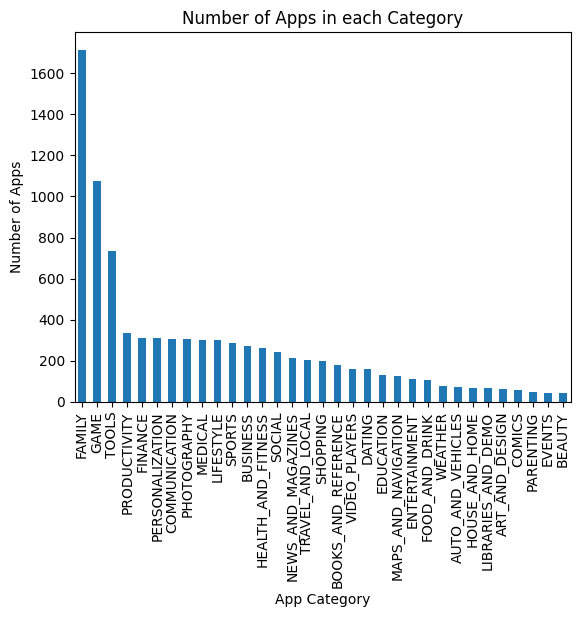

In [44]:
ax = df_apps_clean.Category.value_counts().plot(kind='bar')
ax.set_xlabel('App Category')
ax.set_ylabel('Number of Apps')
ax.set_title('Number of Apps in each Category')
plt.show()

In [40]:
# top10_category = df_apps_clean.Category.value_counts()[:10]
top10_category = df_apps_clean['Category'].value_counts().head(10)
top10_category

,count
Category,
FAMILY,1714
GAME,1074
TOOLS,733
PRODUCTIVITY,334
FINANCE,311
PERSONALIZATION,310
COMMUNICATION,307
PHOTOGRAPHY,304
MEDICAL,302


### Vertical Bar Chart - Highest Competition (Number of Apps)

In [45]:
bar = px.bar(x=top10_category.index, y=top10_category.values, labels={'x': 'Category', 'y': 'Number of Apps'})
bar.show()

### Horizontal Bar Chart - Most Popular Categories (Highest Downloads)

In [48]:
category_installs = df_apps_clean.groupby('Category').agg({'Installs': pd.Series.sum})
category_installs.sort_values('Installs', ascending=True, inplace=True)

In [49]:
h_bar = px.bar(x = category_installs.Installs,
               y = category_installs.index,
               orientation='h')

h_bar.show()

### Category Concentration - Downloads vs. Competition

**Challenge**:
* First, create a DataFrame that has the number of apps in one column and the number of installs in another:

<img src=https://imgur.com/uQRSlXi.png width="350">

* Then use the [plotly express examples from the documentation](https://plotly.com/python/line-and-scatter/) alongside the [.scatter() API reference](https://plotly.com/python-api-reference/generated/plotly.express.scatter.html)to create scatter plot that looks like this.

<img src=https://imgur.com/cHsqh6a.png>

*Hint*: Use the size, hover_name and color parameters in .scatter(). To scale the yaxis, call .update_layout() and specify that the yaxis should be on a log-scale like so: yaxis=dict(type='log')

In [50]:
cat_number = df_apps_clean.groupby('Category').agg({'App': pd.Series.count})

In [51]:
cat_merged_df = pd.merge(cat_number, category_installs, on='Category', how="inner")
print(f'The dimensions of the DataFrame are: {cat_merged_df.shape}')
cat_merged_df.sort_values('Installs', ascending=False)

The dimensions of the DataFrame are: (33, 2)


,App,Installs
Category,,
GAME,1074,31543862717
COMMUNICATION,307,24152241530
SOCIAL,244,12513841475
PRODUCTIVITY,334,12463070180
TOOLS,733,11440724500
FAMILY,1714,10041105490
PHOTOGRAPHY,304,9721243130
TRAVEL_AND_LOCAL,205,6361859300
VIDEO_PLAYERS,160,6221897200


In [77]:
scatter = px.scatter(cat_merged_df, # data
                    x='App', # column name
                    y='Installs',
                    title='Category Concentration',
                    size='App',
                    hover_name=cat_merged_df.index,
                    color='Installs')

scatter.update_layout(xaxis_title="Number of Apps (Lower=More Concentrated)",
                      yaxis_title="Installs",
                      yaxis=dict(type='log'))

scatter.show()

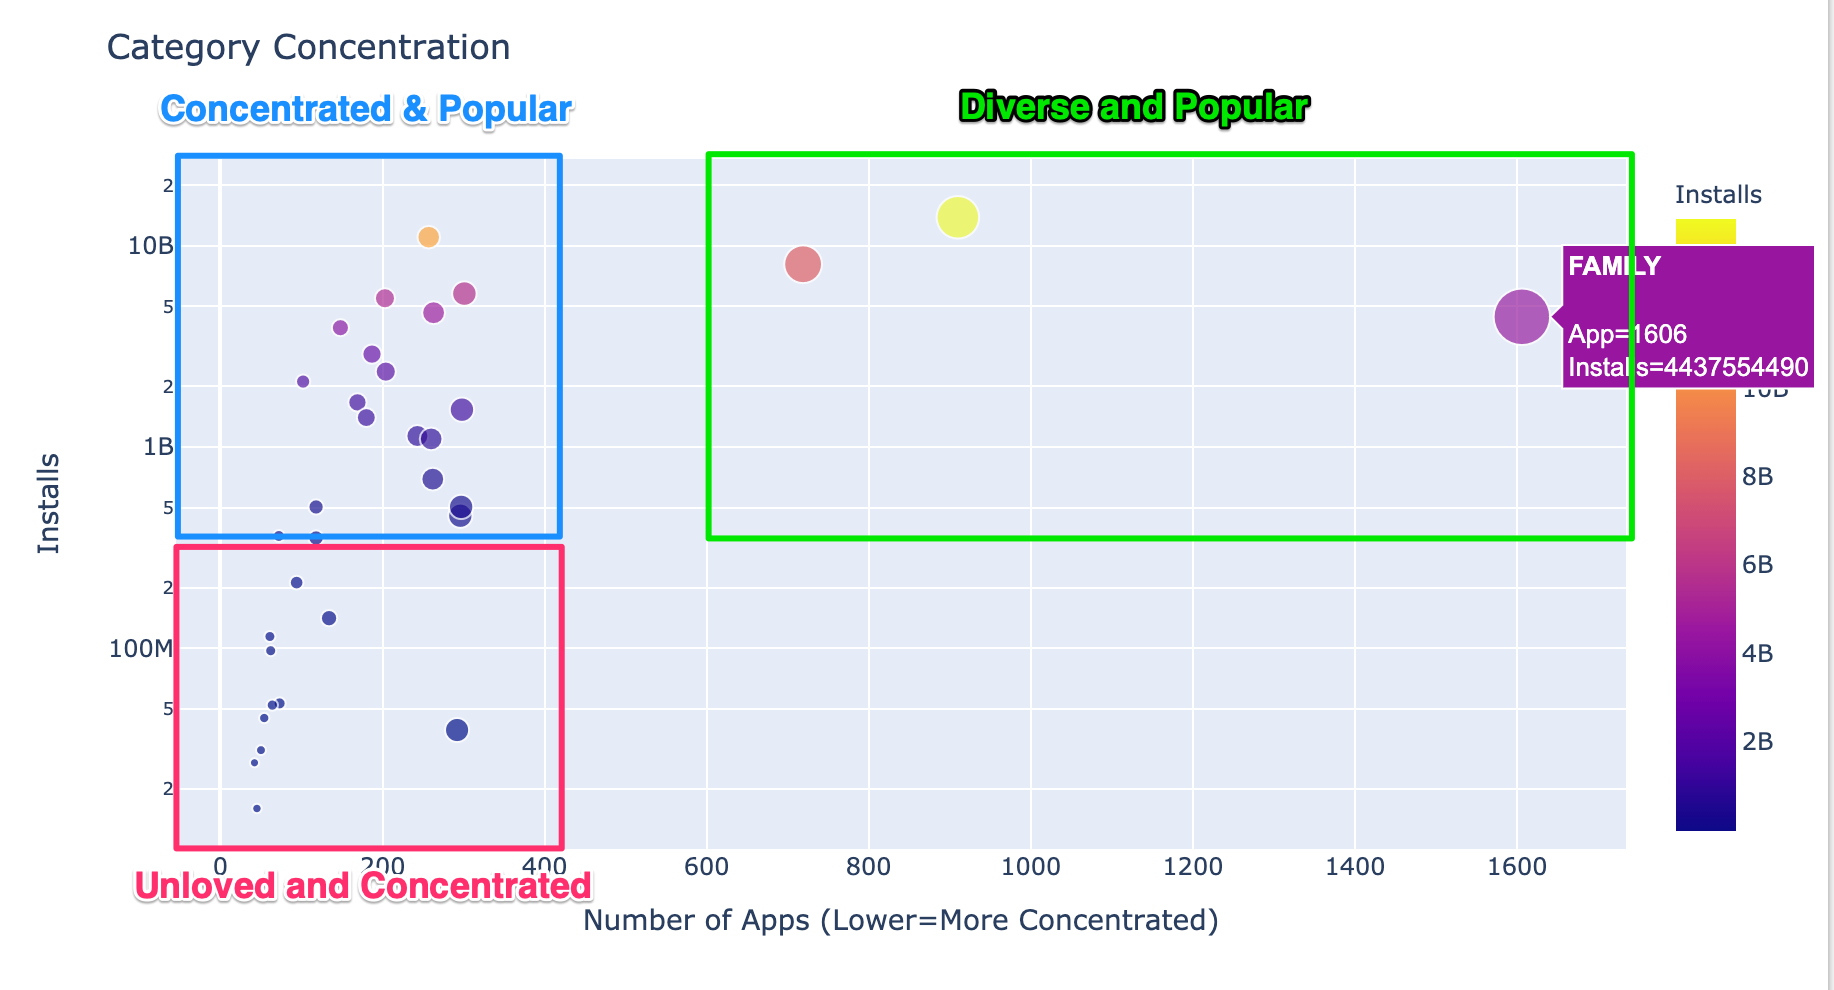

# Extracting Nested Data from a Column

**Challenge**: How many different types of genres are there? Can an app belong to more than one genre? Check what happens when you use .value_counts() on a column with nested values? See if you can work around this problem by using the .split() function and the DataFrame's [.stack() method](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.stack.html).


In [53]:
# Step 1: Check the structure of the 'Genre' column (or 'Category' column)
df_apps_clean['Genres'].head()

# Step 2: Use .split() to separate genres
# Assuming genres are separated by commas, we will apply .split(',') to each entry in the 'Genres' column
df_apps_clean['Genres'] = df_apps_clean['Genres'].apply(lambda x: x.split(','))

# Step 3: Stack the 'Genres' column to flatten the list of genres into a single column
genres_stack = df_apps_clean['Genres'].explode()

# Step 4: Use .value_counts() to count the occurrences of each genre
genre_counts = genres_stack.value_counts()

# Step 5: Show the number of unique genres and the top genre counts
print(f"Total unique genres: {len(genre_counts)}")
print("Top 10 genres:")
print(genre_counts.head(10))


Total unique genres: 115
Top 10 genres:
Genres
Tools              732
Entertainment      494
Education          446
Action             349
Productivity       334
Finance            311
Personalization    310
Communication      307
Photography        304
Medical            302
Name: count, dtype: int64


# Colour Scales in Plotly Charts - Competition in Genres

**Challenge**: Can you create this chart with the Series containing the genre data?

<img src=https://imgur.com/DbcoQli.png width=400>

Try experimenting with the built in colour scales in Plotly. You can find a full list [here](https://plotly.com/python/builtin-colorscales/).

* Find a way to set the colour scale using the color_continuous_scale parameter.
* Find a way to make the color axis disappear by using coloraxis_showscale.

In [59]:
genres_stack = df_apps_clean['Genres'].explode()

genre_counts = genres_stack.value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

fig = px.bar(
    genre_counts[:10],
    x='Genre',
    y='Count',
    color='Count',  # Color by the count of each genre
    color_continuous_scale='Plasma',  # Experiment with different color scales like 'Viridis', 'Cividis', 'Plasma', etc.
    title='Competition in Genres'
)

# Remove the color scale from the chart
fig.update_layout(coloraxis_showscale=False)

fig.show()

# Grouped Bar Charts: Free vs. Paid Apps per Category

In [65]:
df_apps_clean.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size_MBs', 'Installs', 'Type',
       'Price', 'Content_Rating', 'Genres', 'Revenue_Estimate'],
      dtype='object')

In [64]:
import plotly.express as px

**Challenge**: Use the plotly express bar [chart examples](https://plotly.com/python/bar-charts/#bar-chart-with-sorted-or-ordered-categories) and the [.bar() API reference](https://plotly.com/python-api-reference/generated/plotly.express.bar.html#plotly.express.bar) to create this bar chart:

<img src=https://imgur.com/LE0XCxA.png>

You'll want to use the `df_free_vs_paid` DataFrame that you created above that has the total number of free and paid apps per category.

See if you can figure out how to get the look above by changing the `categoryorder` to 'total descending' as outlined in the documentation here [here](https://plotly.com/python/categorical-axes/#automatically-sorting-categories-by-name-or-total-value).

In [69]:
df_free_vs_paid = df_apps_clean.groupby(['Category', 'Type']).size().reset_index(name='Count')
# Create the grouped bar chart
fig = px.bar(
    df_free_vs_paid,
    x='Category',         # Categories on the x-axis
    y='Count',            # Count of apps
    color='Type',         # Differentiate between 'Free' and 'Paid' apps
    barmode='group',      # Group bars for each category
    title='Free vs Paid Apps per Category', # Title of the chart
    labels={'Count': 'Number of Apps'}, # Y-axis label
    category_orders={'Category': df_free_vs_paid.groupby('Category')['Count'].sum().sort_values(ascending=False).index.tolist()},  # Sort categories by total number of apps
)

# Show the chart
fig.show()

In [67]:
df_apps_clean.Type.value_counts()

,count
Type,
Free,8278
Paid,598


In [70]:

df_free_vs_paid = df_apps_clean.groupby(["Category", "Type"], as_index=False).agg({'App': pd.Series.count})
df_free_vs_paid.head()

,Category,Type,App
0,ART_AND_DESIGN,Free,59
1,ART_AND_DESIGN,Paid,3
2,AUTO_AND_VEHICLES,Free,72
3,AUTO_AND_VEHICLES,Paid,1
4,BEAUTY,Free,42


In [71]:
g_bar = px.bar(df_free_vs_paid,
               x='Category',
               y='App',
               title='Free vs Paid Apps by Category',
               color='Type',
               barmode='group')

g_bar.update_layout(xaxis_title='Category',
                    yaxis_title='Number of Apps',
                    xaxis={'categoryorder':'total descending'},
                    yaxis=dict(type='log'))

g_bar.show()

# Plotly Box Plots: Lost Downloads for Paid Apps

**Challenge**: Create a box plot that shows the number of Installs for free versus paid apps. How does the median number of installations compare? Is the difference large or small?

Use the [Box Plots Guide](https://plotly.com/python/box-plots/) and the [.box API reference](https://plotly.com/python-api-reference/generated/plotly.express.box.html) to create the following chart.

<img src=https://imgur.com/uVsECT3.png>


In [72]:
box = px.box(df_apps_clean,
             y='Installs',
             x='Type',
             color='Type',
             notched=True,
             points='all',
             title='How Many Downloads are Paid Apps Giving Up?')

box.update_layout(yaxis=dict(type='log'))

box.show()

# Plotly Box Plots: Revenue by App Category

**Challenge**: See if you can generate the chart below:

<img src=https://imgur.com/v4CiNqX.png>

Looking at the hover text, how much does the median app earn in the Tools category? If developing an Android app costs $30,000 or thereabouts, does the average photography app recoup its development costs?

Hint: I've used 'min ascending' to sort the categories.

In [73]:
df_paid_apps = df_apps_clean[df_apps_clean['Type'] == 'Paid']
box = px.box(df_paid_apps,
             x='Category',
             y='Revenue_Estimate',
             title='How Much Can Paid Apps Earn?')

box.update_layout(xaxis_title='Category',
                  yaxis_title='Paid App Ballpark Revenue',
                  xaxis={'categoryorder':'min ascending'},
                  yaxis=dict(type='log'))


box.show()

# How Much Can You Charge? Examine Paid App Pricing Strategies by Category

**Challenge**: What is the median price price for a paid app? Then compare pricing by category by creating another box plot. But this time examine the prices (instead of the revenue estimates) of the paid apps. I recommend using `{categoryorder':'max descending'}` to sort the categories.

In [74]:
df_paid_apps.Price.median()

2.99

In [76]:
box = px.box(df_paid_apps,
             x='Category',
             y="Price",
             title='Price per Category')

box.update_layout(xaxis_title='Category',
                  yaxis_title='Paid App Price',
                  xaxis={'categoryorder':'max descending'},
                  yaxis=dict(type='log'))

box.show()